<a href="https://colab.research.google.com/github/mcjkurz/qhchina/blob/main/tutorials/Intro_to_Python_for_Chinese_Humanities_Part_2_Working_with_Texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Python for Chinese Humanities: Part 2, Working with Texts

## Reading Files

Let's first download the text file, a novel "Love in a Fallen City" by Eileen Chang 张爱玲.
You can upload your own text (needs to be a .txt file). Simply click the folder icon (文件夾) on the left side and drag the file from your computer there.

In [ ]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/张爱玲_倾城之恋.txt

--2024-06-17 04:08:19--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/%E5%BC%A0%E7%88%B1%E7%8E%B2_%E5%80%BE%E5%9F%8E%E4%B9%8B%E6%81%8B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 86846 (85K) [text/plain]
Saving to: ‘张爱玲_倾城之恋.txt.1’

张爱玲_倾城之恋.txt 100%[===================>]  84.81K  --.-KB/s    in 0.02s   

2024-06-17 04:08:19 (3.88 MB/s) - ‘张爱玲_倾城之恋.txt.1’ saved [86846/86846]



We use the `open` function to read files. `open` takes two arguments: the name of the file and the mode of access to this file.

Here, we use `r` for "read." We need to remember to `close` the file after we finish reading from it.

**Remember to use a correct filename if you use your own text.**

In [83]:
# Option 1
filename = "张爱玲_倾城之恋.txt" # change to your own filename!

my_file = open(filename, "r")
text = my_file.read()
my_file.close()

In [ ]:
# Option 2 (recommended)
filename = "张爱玲_倾城之恋.txt" # change to your own filename
with open(filename, "r") as my_file:
  text = my_file.read()

In [84]:
print("How many characters (including spaces):", len(text))

How many characters (including spaces): 29139


In [85]:
print(text[:200]) # print the first 200 characters

《倾城之恋》

作者：张爱玲

上海为了“节省天光”，将所有的时钟都拨快了一个小时，然而白公馆里说：“我们用的是老钟。”他们的十点钟是人家的十一点。他们唱歌唱走了板，跟不上生命的胡琴。

胡琴咿咿呀呀拉着，在万盏灯的夜晚，拉过来又拉过去，说不尽的苍凉的故事——不问也罢！……胡琴上的故事是应当由光艳的伶人来扮演的，长长的两片红胭脂夹住琼瑶鼻，唱了，笑了，袖子挡住了嘴……然而这里只有白四爷单身坐在黑沉


# Word segmentation for Chinese

Unlike English, in Chinese there are no spaces between words. This is a problem for word analysis.

For very short texts, we can segment them into separate words ourselves.

In [87]:
text = "我今天很開心。"
word_list = ["我", "今天", "很", "開心","。"]
print(len(word_list))

5


In [88]:
for word in word_list:
  print(word)

我
今天
很
開心
。


For larger texts, however, we need some help.

Fortunately, there are free, open-source models that we can use to segment Chinese texts.

In this example, we will use `spacy` model for Chinese, `zh_core_web_lg`. Let's first download and load the model.

In [ ]:
!python -m spacy download zh_core_web_lg
import spacy
nlp = spacy.load("zh_core_web_lg")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.0/603.0 MB 2.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Let's now segment our short sentence ("我今天很開心") using the model we have just downloaded.

We can use the function `nlp` and provide the text as its argument.

The function will return a list of tokens (words), and each token has some important properties. We will use two of them:

*   `token.text` -- this is the actual word
*   `token.pos_` -- this is the part-of-speech tag (noun, verb, etc).



In [90]:
sentence = "我今天很開心。"

segmented_sentence = nlp(sentence) # this will return a list of tokens
print([token.text for token in segmented_sentence]) # let's print a list of token.text

['我', '今天', '很', '開心', '。']


**Part-of-Speech (POS)** is a very useful category. For example, we might want to remove all punctuation marks (。，“； etc.) from our list.

Each token has its tag (called POS-tag). The full list of tags can be seen here: https://universaldependencies.org/u/pos/

In [105]:
print([token.pos_ for token in segmented_sentence])

['PRON', 'NOUN', 'ADV', 'VERB', 'PUNCT']


Let's now read our text again. We will segment it into separate words.

Finally, we will remove punctuation and some "unwanted" words that the model tokenized wrongly (models make mistakes).

In [106]:
# reading the text from file
f = open(filename, "r")
novel_text = f.read()
f.close()

# segmenting the text
segmented_novel = nlp(novel_text)

print("Originally, there were", len(segmented_novel), "tokens.")

forbidden_tags = ["PUNCT", "PROPN", "SYM", "SPACE"] # the tags you want to remove
forbidden_words = ["金枝","流苏","姓范","白老","老太太","方道"] # your own words that you want to remove

# we keep only the tokens that are not punctuation, proper nouns, symbols, and spaces
# we also remove some of the "forbidden words" which were wrongly tagged/segmented
novel_tokens = [token.text for token in segmented_novel if token.pos_ not in forbidden_tags and token.text not in forbidden_words]

print("There are", len(novel_tokens), "after cleaning.")
print(novel_tokens[:10]) # print first 10 tokens

Originally, there were 20220 tokens.
There are 15449 after cleaning.
['作者', '为了', '节省', '天光', '将', '所有', '的', '时钟', '都', '拨']


After cleaning the text, we end up with **15,449** tokens.

The original text had **20,220** tokens, including spaces and punctuation.

## Finding most common and most informative words

Let's find the most frequent tokens in Eileen Chang's novel. We will use the library `collections` and the class `Counter` from this library.

We can use `Counter` as a function, providing the novel_tokens as its argument.

In [93]:
from collections import Counter

novel_counter = Counter(novel_tokens)
novel_counter.most_common(20) # print the 20 most common tokens

[('的', 862),
 ('了', 641),
 ('她', 392),
 ('一', 242),
 ('是', 241),
 ('着', 239),
 ('你', 215),
 ('我', 195),
 ('不', 191),
 ('在', 187),
 ('他', 182),
 ('也', 127),
 ('上', 114),
 ('人', 103),
 ('就', 103),
 ('里', 97),
 ('那', 95),
 ('柳原', 93),
 ('太太', 89),
 ('去', 89)]

In [94]:
# Counter is actually a dictionary!
# We can check how many times a token shows up by just looking up its value in the dictionary
print(novel_counter["她"])
print(novel_counter["abc"])

392
0


A word that occurs most often, such as 的 or 了, is not the most informative word.

The problem is: we need to find the words that appear **more often than expected and are, therefore, informative.**

Each word in a language has a certain average probability of occurring.

For example, the words "的" or "去" are much more likely than 漢堡 in Chinese.

Let's start with a small example.

In [96]:
word_list = ["我","今天","很","开心","我"]

count_of_我 = word_list.count("我")

number_of_words = len(word_list)

print("There are " + str(number_of_words) + " words in the list and the word 我 appears " + str(count_of_我) + " times.")

normalized_count = count_of_我 / number_of_words

print("Its probability is " + str(normalized_count) + ".")

There are 5 words in the list and the word 我 appears 2 times.
Its probability is 0.4.


We can repeat this for each unique word.

To get unique words, we use the set() function which changes the list (where an element can be repeated, such as 我 in the example) to a set.

A set contains only unique elements!

In [97]:
word_set = set(word_list)
normalized_counts = [(word, word_list.count(word) / number_of_words) for word in word_set]
print(normalized_counts)

[('开心', 0.2), ('今天', 0.2), ('很', 0.2), ('我', 0.4)]


We can do the same for a large corpus of texts, not just our one sentence or even the whole novel.

In this way, we can get an (approximate) average probability of each word in the Chinese language.

This has already been done by other scholars. Let's download these probabilities now.

In [98]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/chinese_word_freqs.json
import json
with open("chinese_word_freqs.json", "r") as f:
  global_probs = json.load(f)

--2024-06-18 06:12:38--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/chinese_word_freqs.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7541058 (7.2M) [text/plain]
Saving to: ‘chinese_word_freqs.json.3’

chinese_word_freqs. 100%[===================>]   7.19M  --.-KB/s    in 0.09s   

2024-06-18 06:12:38 (80.5 MB/s) - ‘chinese_word_freqs.json.3’ saved [7541058/7541058]



What is the probability of the word "我" in an average Chinese text?

In [99]:
global_probs["我"]

0.010069128495994678

This means the word "我“ appears with the probability 0.01 (or 1%).

This means: for every 100 Chinese words, there should be at least one 我 on average.

Let's find how many words are there in our text, excluding the puncutation, proper nouns, etc.

In [100]:
total_words_in_novel = len(novel_tokens)
print("There are", total_words_in_novel, "words in 'Love in a Fallen City.'")

There are 15449 words in 'Love in a Fallen City.'


Now, we know that the word "我" should appear in ≈1% of them.

It means that **"我" should appear around 15,452 * 0.01 times, or ≈155 times.**

It should, but maybe it appears more often. Let's check.


In [65]:
should_appear_times = global_probs["我"] * total_words_in_novel

print("The word 我 should appear", should_appear_times, "times in the novel. In fact, it appears", novel_counter["我"], "times.")
print("It appears", novel_counter["我"]/should_appear_times, "times more often than it should.")

The word 我 should appear 155.55796613462178 times in the novel. In fact, it appears 195 times.
It appears 1.2535520028028948 times more often than it should.


1.2535 is not a big value. But still, from this perspective, 我 becomes important for our text since it appears more often than expected.

Let's repeat this process for every unique word in the novel.

We need to first find the unique words.

In [101]:
novel_unique_tokens = set(novel_tokens)
print("There are", len(novel_unique_tokens), "unique tokens in the 'Love in the Fallen City.'")

There are 4549 unique tokens in the 'Love in the Fallen City.'


Now, we need to check which of these unique words appears much more often than expected.

As said before, we can calculate the expected number of occurrences using a much larger corpus of Chinese texts to give us probability for each word in an "average" Chinese language.

We can then compare this probability with the probability of the word as it occurs in a particular text, for example, our selected novel.

We will make a dictionary `token_ratios_dict` and store each ratio in it.

In [77]:
token_ratios_dict = {}

for unique_token in novel_unique_tokens: # for each unique word
  if unique_token in global_probs.keys(): # checking if the token appears in the global_freqs dictionary ("average Chinese")
    should_appear = global_probs[unique_token] * total_words_in_novel
    token_ratios_dict[unique_token] = novel_counter[unique_token] / should_appear

# Let's check if our value is confirmed.
token_ratios_dict["我"]

1.2535520028028948

Once again, each key-value pair in the `token_ratios_dict` dictionary tells us **how many times more often (or less often for values `< 1`) a given word appears in the novel.**

Let's see the pronoun 她, does it appear more (`value > 1`) or less often (`value < 1`) than it "should"?

In [102]:
token_ratios_dict["她"]

15.993546950484703

Wow! Eileen Chang really likes to use the feminine pronoun.

Now let's sort the terms in decreasing order, from the highest to the lowest ratio.

In [103]:
# dictionaries cannot be sorted; we need to first change the dictionary into a list of tuples (token, ratio)
token_ratios_list = token_ratios_dict.items()

# take the second element (r[1]) as the key by which to sort (second element is the ratio)
# we place the minus before it to make the descending order
token_ratios_list = sorted(token_ratios_list, key = lambda element:-element[1])
token_ratios_list[:20] # top 20 elements

[('开仗', 3431.491646545342),
 ('吊子', 2846.86714380058),
 ('容得', 2341.777811835961),
 ('胡琴', 2028.4832358240376),
 ('刺挠', 1947.9904874842966),
 ('一男半女', 1709.46104003724),
 ('思道', 1665.0255084154771),
 ('下劲', 1637.4837330883036),
 ('绝子绝孙', 1589.6739890565284),
 ('徐太太', 1555.6095464338887),
 ('承情', 1495.778410032585),
 ('带累', 1479.51994905397),
 ('蔻丹', 1412.3562678388093),
 ('寒苦', 1388.9370950302575),
 ('个人主义者', 1276.5846219269895),
 ('舞场', 1218.3113476210806),
 ('递信', 1212.6132321867726),
 ('阔人', 1191.3858670719057),
 ('忠孝节义', 1115.7035681390594),
 ('扫帚星', 1103.269181868006)]

The word "胡琴" appears 3431 times more often than expected! That's very surprising.

We see another problem, however. Phrases like "开仗" or "一男半女" might be very rare in the text, but even rarer in the global corpus ("average Chinese"), which pushes them up the hierarchy. We need to find a balance between the word's rarity and its informativeness. Let's filter this list and retain only the elements that are present in the novel at least 4 times.

In [104]:
token_ratios_list = [(token, ratio) for token,ratio in token_ratios_list if novel_counter[token] >= 4]
token_ratios_list[:20]

[('胡琴', 2028.4832358240376),
 ('舞场', 1218.3113476210806),
 ('太太', 368.28045457348645),
 ('堂屋', 318.93583730064347),
 ('好容易', 144.39125936534137),
 ('发胖', 82.2964976290908),
 ('搁', 80.50533651791825),
 ('方才', 74.32992762934268),
 ('顽固', 73.57115617213174),
 ('窗子', 72.45503243753556),
 ('胡乱', 57.90931091808774),
 ('底下', 56.5754571630904),
 ('旅馆', 54.54041634337843),
 ('可不', 53.248769303549274),
 ('只怕', 46.226057113299426),
 ('英国人', 45.17130920593206),
 ('半晌', 42.17335937892631),
 ('呃', 41.15851375269672),
 ('下楼', 40.724895189116936),
 ('只得', 40.61507381340134)]

That's it! **We have found some of the most characteristic words of the novel!**

Terms such as 胡琴 (huqin), 舞场 (dance floor), 太太 (lady), 堂屋 (dining room) constitute the most important images of this story.

We can now use these words in the next part of the project (e.g., close reading).

We can also visualize them. Let's make a wordcloud.

# Making a wordcloud from the informative words

We need to first download the Chinese font, as Python does not support Chinese language visualization by default.

In [69]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf

--2024-06-18 05:38:15--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11697600 (11M) [application/octet-stream]
Saving to: ‘STSong.ttf’

STSong.ttf          100%[===================>]  11.16M  --.-KB/s    in 0.1s    

2024-06-18 05:38:16 (91.7 MB/s) - ‘STSong.ttf’ saved [11697600/11697600]



You can read more about the WordCloud class here: https://amueller.github.io/word_cloud/generated/wordcloud.WordCloud.html

You can choose different color maps: https://matplotlib.org/stable/gallery/color/colormap_reference.html

The following code will generate a wordcloud and save it as "wordcloud.png" in the local directory. You can download it to your computer.

If you don't like the final result, you can run the code as many times as you wish.

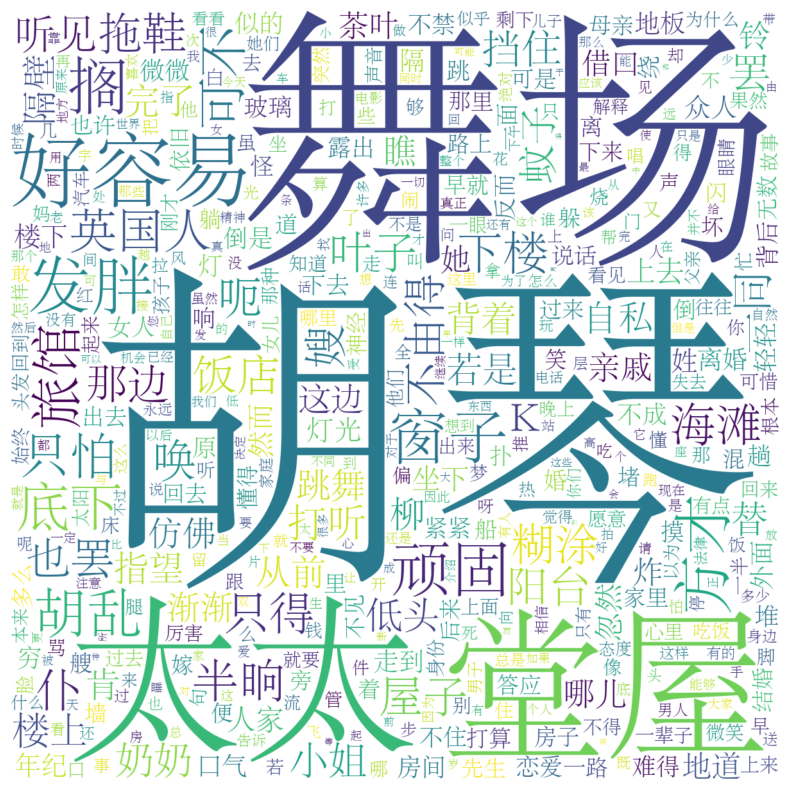

In [71]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image

# Convert back to a dictionary (WordCloud requires a dictionary)
frequencies_dict = dict(token_ratios_list)

# Generate word cloud
wordcloud = WordCloud(font_path='STSong.ttf', colormap="viridis", max_words=500, width=1200, height=1200, background_color='white')

wordcloud.generate_from_frequencies(frequencies_dict)

# Display the generated word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

We can also use a mask to give the wordcloud a specific shape or change the color palette. Here, I use the mask in the shape of a woman silhouette. I use the colormap `plasma`.

The generation will take much longer though (around 2 mins for these particular settings!)

After generation, you should download the file ("wordcloud_masked.png").

--2024-06-18 05:40:22--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/woman_silhouette.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 316910 (309K) [image/png]
Saving to: ‘woman_silhouette.png’

woman_silhouette.pn 100%[===================>] 309.48K  --.-KB/s    in 0.04s   

2024-06-18 05:40:22 (6.88 MB/s) - ‘woman_silhouette.png’ saved [316910/316910]



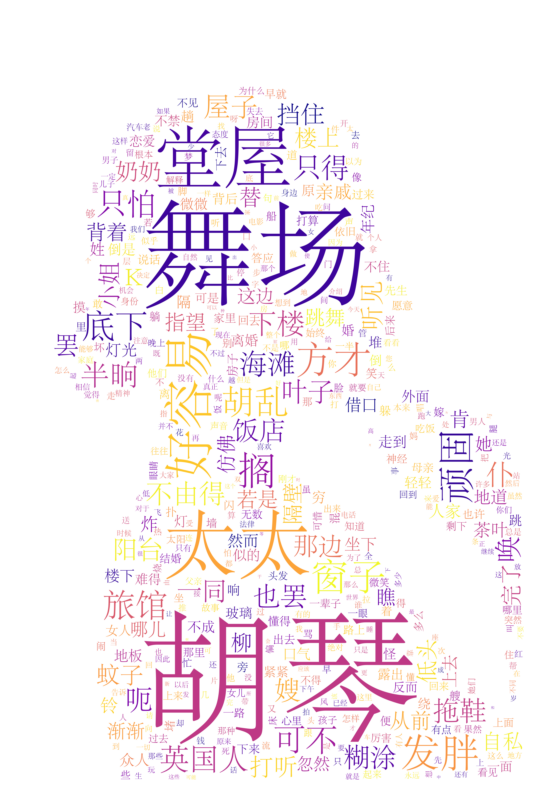

In [72]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/woman_silhouette.png
mask = np.array(Image.open('woman_silhouette.png'))

# Generate word cloud
wordcloud = WordCloud(font_path='STSong.ttf', mask=mask, colormap='plasma', max_words=500, width=1200, height=1200, background_color='white')
wordcloud.generate_from_frequencies(frequencies_dict)

# Display the generated word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud_masked.png", format="png", dpi=300, bbox_inches="tight")
plt.show()